# Instacart Frequent Itemset Mining

**IA2 — Advanced Data Analytics (216H03C701), Semester VII, AY 2026–27**

This reproducible notebook mines and evaluates product associations in the
public Instacart Market Basket Analysis dataset. It is an academic analogue:
Instacart documents co-purchase scoring plus ML ranking, but does not disclose
Apriori or FP-Growth as its production implementation.

## Learning objectives and workflow

1. Load the Kaggle data with a manual-upload fallback.
2. Validate tables and explore basket behaviour.
3. Create a bounded sparse basket matrix.
4. compare Apriori and FP-Growth.
5. Generate and inspect association rules.
6. Recommend complements and evaluate on held-out baskets.
7. Interpret scalability, limitations, responsible use, and modern AI.

**Data note:** accept the Kaggle competition rules before downloading. Do not
commit the CSV files. Defaults are designed for a normal Colab CPU runtime.

In [2]:
%pip -q install "mlxtend>=0.23" "kagglehub>=0.3" "psutil>=5.9"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from __future__ import annotations

import os
import platform
import random
import time
import warnings
import zipfile
import hashlib
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import seaborn as sns
from IPython.display import display
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42
MAX_ORDERS = 30_000       # bounded mining sample
TOP_N_PRODUCTS = 250      # controls transaction-matrix width
MIN_SUPPORT = 0.003
MIN_CONFIDENCE = 0.10
MIN_LIFT = 1.05
MAX_ITEMSET_LEN = 3
TOP_K = 10

random.seed(SEED)
np.random.seed(SEED)
print({
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "ram_gb": round(psutil.virtual_memory().total / 2**30, 1),
    "seed": SEED,
})

{'python': '3.14.6', 'pandas': '3.0.5', 'ram_gb': 15.7, 'seed': 42}


## Download or locate the data

Kaggle may require account authentication and acceptance of the competition
rules. If automatic download fails, download the archive from the competition
page, unzip it, and set `DATA_DIR` to the folder containing the CSV files.

In [4]:
REQUIRED = {
    "orders.csv",
    "products.csv",
    "aisles.csv",
    "departments.csv",
    "order_products__prior.csv",
    "order_products__train.csv",
}


def locate_csv_dir(root: Path) -> Path | None:
    """Return the first descendant containing all required competition CSVs."""
    candidates = [root] + [p for p in root.rglob("*") if p.is_dir()]
    for candidate in candidates:
        if REQUIRED.issubset({p.name for p in candidate.glob("*.csv")}):
            return candidate
    return None


DATA_ROOT = Path(os.environ.get("INSTACART_DATA_DIR", str(Path.cwd() / "data")))
DATA_ROOT.mkdir(parents=True, exist_ok=True)
DATA_DIR = locate_csv_dir(DATA_ROOT)

# The repository hosts the complete CSV bundle as a GitHub Release asset.
# This works both for clones and notebooks opened directly in Colab.
BUNDLE_NAME = "instacart-market-basket-analysis-data.zip"
BUNDLE_SHA256 = "b0c58b80af5c43bcdebf34909033b740fc312353d2b8aa5f442083c824e8311d"
BUNDLE_URL = (
    "https://github.com/shreejaykurhade/instacart-frequent-itemset-mining/"
    f"releases/download/dataset-v1/{BUNDLE_NAME}"
)

if DATA_DIR is None:
    try:
        bundle = Path.cwd() / BUNDLE_NAME
        if not bundle.exists():
            bundle = DATA_ROOT / BUNDLE_NAME
            print("Downloading dataset bundle from GitHub:", BUNDLE_URL)
            urlretrieve(BUNDLE_URL, bundle)
        with bundle.open("rb") as stream:
            digest = hashlib.file_digest(stream, "sha256").hexdigest()
        if digest != BUNDLE_SHA256:
            raise ValueError("Dataset bundle checksum mismatch (or Git LFS pointer downloaded)")
        with zipfile.ZipFile(bundle) as archive:
            if set(archive.namelist()) != REQUIRED:
                raise ValueError("Dataset bundle contains unexpected filenames")
            archive.extractall(DATA_ROOT)
        DATA_DIR = locate_csv_dir(DATA_ROOT)
        print("Dataset bundle verified and extracted")
    except Exception as exc:
        print("GitHub dataset bundle unavailable:", exc)

if DATA_DIR is None:
    try:
        import kagglehub

        downloaded = Path(
            kagglehub.competition_download("instacart-market-basket-analysis")
        )
        if downloaded.is_file() and downloaded.suffix == ".zip":
            extract_to = DATA_ROOT / "instacart"
            extract_to.mkdir(exist_ok=True)
            with zipfile.ZipFile(downloaded) as archive:
                archive.extractall(extract_to)
            DATA_DIR = locate_csv_dir(extract_to)
        else:
            DATA_DIR = locate_csv_dir(downloaded)
    except Exception as exc:
        print("Automatic Kaggle download unavailable:", exc)

# Public mirror fallback for readers without Kaggle API credentials. These are
# the same six competition CSVs; Kaggle remains the canonical dataset source.
if DATA_DIR is None:
    try:
        from urllib.request import urlretrieve

        mirror = (
            "https://huggingface.co/datasets/attik/"
            "Instacart-Market-Basket-Analysis/resolve/main"
        )
        mirror_dir = DATA_ROOT / "instacart"
        mirror_dir.mkdir(exist_ok=True)
        for filename in sorted(REQUIRED):
            destination = mirror_dir / filename
            if not destination.exists():
                print("Downloading public mirror:", filename)
                urlretrieve(f"{mirror}/{filename}", destination)
        DATA_DIR = locate_csv_dir(mirror_dir)
    except Exception as exc:
        print("Public-mirror download unavailable:", exc)

if DATA_DIR is None:
    raise FileNotFoundError(
        "Instacart CSVs not found. Upload/unzip the Kaggle archive under "
        f"{DATA_ROOT} or set INSTACART_DATA_DIR. Required: {sorted(REQUIRED)}"
    )

print("Using data from:", DATA_DIR)

GitHub dataset bundle unavailable: HTTP Error 404: Not Found


c:\Users\hp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Automatic Kaggle download unavailable: User is not authenticated
Using data from: c:\Users\hp\OneDrive\Projects\instacart-frequent-itemset-mining\data\instacart


In [6]:
pip install -q jinja2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
orders = pd.read_csv(
    DATA_DIR / "orders.csv",
    dtype={
        "order_id": "int32", "user_id": "int32", "eval_set": "category",
        "order_number": "int16", "order_dow": "int8",
        "order_hour_of_day": "int8", "days_since_prior_order": "float32",
    },
)
products = pd.read_csv(
    DATA_DIR / "products.csv",
    dtype={"product_id": "int32", "aisle_id": "int16", "department_id": "int8"},
)
aisles = pd.read_csv(DATA_DIR / "aisles.csv", dtype={"aisle_id": "int16"})
departments = pd.read_csv(
    DATA_DIR / "departments.csv", dtype={"department_id": "int8"}
)
prior = pd.read_csv(
    DATA_DIR / "order_products__prior.csv",
    dtype={
        "order_id": "int32", "product_id": "int32",
        "add_to_cart_order": "int16", "reordered": "int8",
    },
)
train = pd.read_csv(
    DATA_DIR / "order_products__train.csv",
    dtype={
        "order_id": "int32", "product_id": "int32",
        "add_to_cart_order": "int16", "reordered": "int8",
    },
)

assert orders.order_id.is_unique
assert products.product_id.is_unique
assert set(prior.order_id).issubset(set(orders.order_id))
assert prior[["order_id", "product_id"]].duplicated().sum() == 0

summary = pd.DataFrame({
    "table": ["orders", "prior items", "train items", "products", "users"],
    "rows_or_count": [len(orders), len(prior), len(train), len(products), orders.user_id.nunique()],
})
display(summary.style.format({"rows_or_count": "{:,}"}))

,table,rows_or_count
0,orders,"3,421,083"
1,prior items,"32,434,489"
2,train items,"1,384,617"
3,products,"49,688"
4,users,"206,209"


## Exploratory data analysis

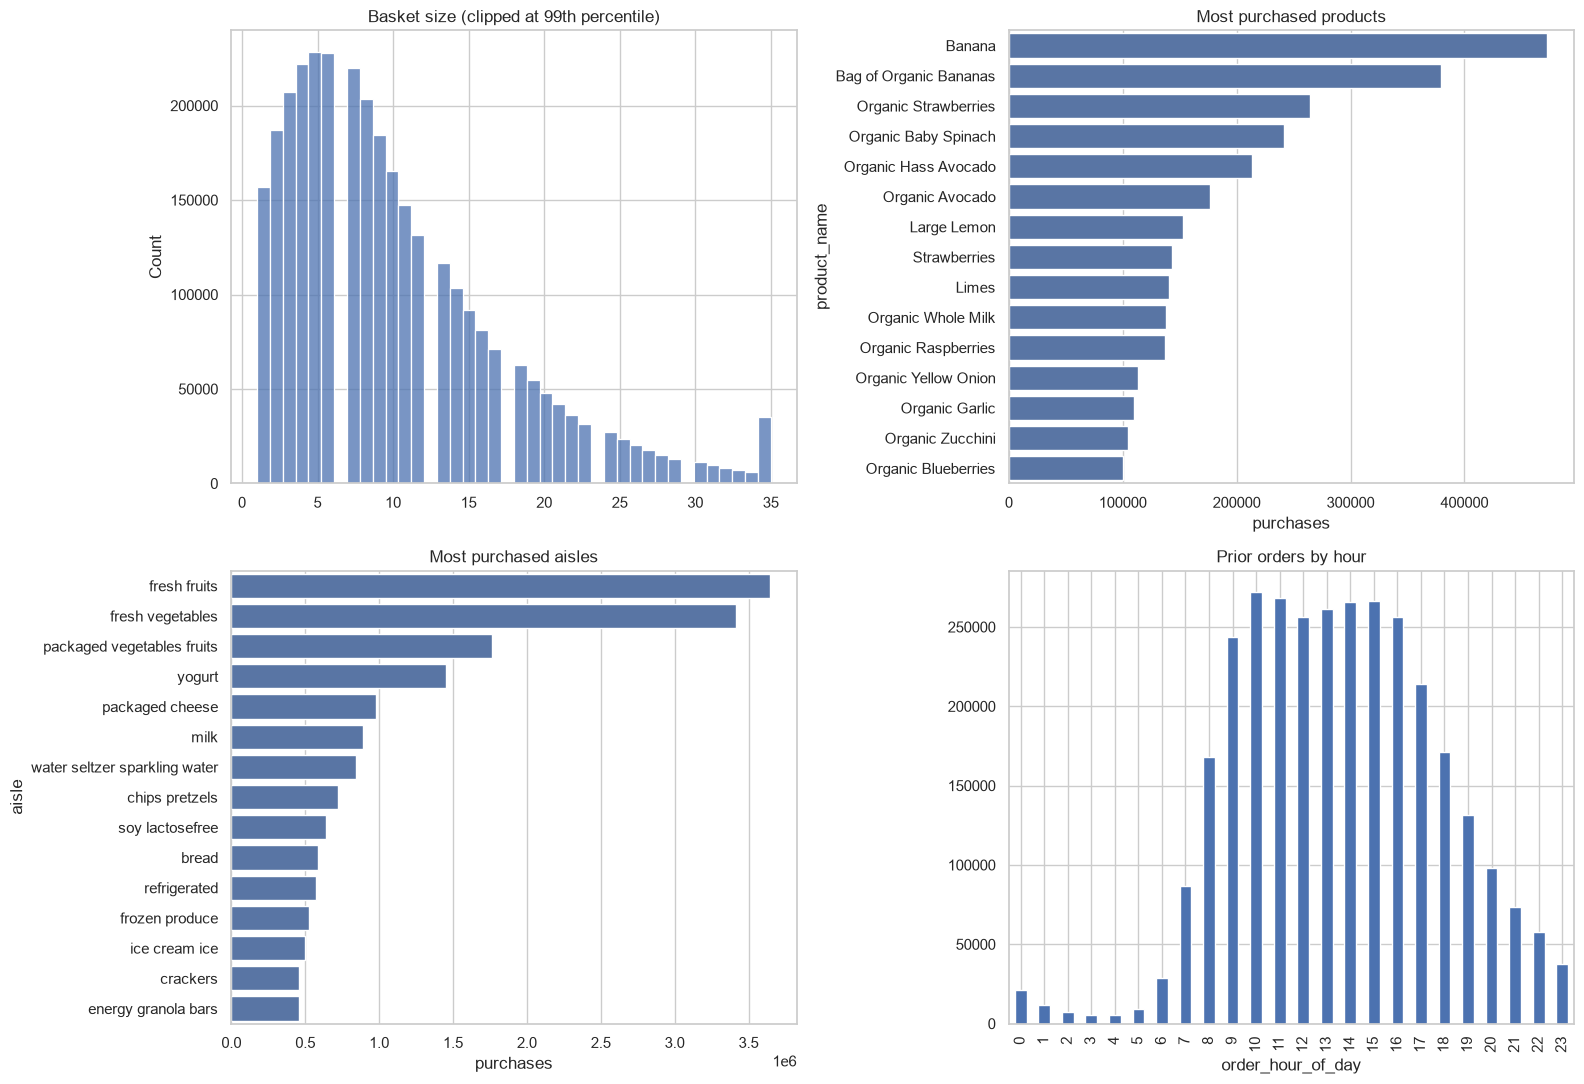

Median basket size: 8.0
Prior-item reorder rate: 0.5897


In [10]:
product_dim = products.merge(aisles, on="aisle_id", how="left").merge(
    departments, on="department_id", how="left"
)
prior_orders = orders.loc[orders.eval_set == "prior", [
    "order_id", "user_id", "order_number", "order_dow", "order_hour_of_day"
]]
prior_named = prior.merge(product_dim, on="product_id", how="left")

basket_sizes = prior.groupby("order_id", observed=True).size()
top_products = (
    prior_named.groupby(["product_id", "product_name"], observed=True)
    .size().sort_values(ascending=False).head(15).rename("purchases").reset_index()
)
top_aisles = (
    prior_named.groupby("aisle", observed=True).size()
    .sort_values(ascending=False).head(15).rename("purchases").reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
sns.histplot(basket_sizes.clip(upper=basket_sizes.quantile(.99)), bins=40, ax=axes[0, 0])
axes[0, 0].set_title("Basket size (clipped at 99th percentile)")
sns.barplot(data=top_products, y="product_name", x="purchases", ax=axes[0, 1])
axes[0, 1].set_title("Most purchased products")
sns.barplot(data=top_aisles, y="aisle", x="purchases", ax=axes[1, 0])
axes[1, 0].set_title("Most purchased aisles")
hourly = prior_orders.groupby("order_hour_of_day", observed=True).size()
hourly.plot(kind="bar", ax=axes[1, 1], title="Prior orders by hour")
plt.tight_layout()
plt.show()

print("Median basket size:", basket_sizes.median())
print("Prior-item reorder rate:", round(prior.reordered.mean(), 4))

## Leakage-resistant development split

Each sampled user’s last **prior** order is held out for evaluation. Earlier
prior orders form the mining set. This avoids using the target basket to build
its own rules. The official `train` table is not used because it covers only
the competition's train users and creates a different sampling frame.

In [11]:
last_prior = prior_orders.groupby("user_id", observed=True)["order_number"].transform("max")
order_split = prior_orders.assign(
    split=np.where(prior_orders.order_number.eq(last_prior), "validation", "mining")
)
eligible_users = order_split.groupby("user_id", observed=True).size()
eligible_users = eligible_users[eligible_users >= 2].index.to_numpy()

rng = np.random.default_rng(SEED)
sampled_users = rng.choice(
    eligible_users,
    size=min(len(eligible_users), max(2_000, MAX_ORDERS // 5)),
    replace=False,
)
sampled_meta = order_split[order_split.user_id.isin(sampled_users)]
mining_ids_all = sampled_meta.loc[sampled_meta.split == "mining", "order_id"].to_numpy()
mining_ids = rng.choice(
    mining_ids_all, size=min(MAX_ORDERS, len(mining_ids_all)), replace=False
)
validation_ids = sampled_meta.loc[sampled_meta.split == "validation", "order_id"].to_numpy()

mining_items = prior[prior.order_id.isin(mining_ids)].copy()
validation_items = prior[prior.order_id.isin(validation_ids)].copy()

popular_ids = mining_items.product_id.value_counts().head(TOP_N_PRODUCTS).index
mining_top = mining_items[mining_items.product_id.isin(popular_ids)]
name_map = product_dim.set_index("product_id").product_name.to_dict()

print({
    "mining_orders": mining_top.order_id.nunique(),
    "validation_orders": validation_items.order_id.nunique(),
    "products_retained": mining_top.product_id.nunique(),
    "mining_rows": len(mining_top),
})

{'mining_orders': 24423, 'validation_orders': 6000, 'products_retained': 250, 'mining_rows': 101746}


## Sparse basket encoding

Rows are orders, columns are retained products, and values indicate presence.
`SparseDtype` prevents the dense Boolean matrix from dominating memory.

In [12]:
basket = pd.crosstab(mining_top.order_id, mining_top.product_id).astype(bool)
basket = basket.astype(pd.SparseDtype(bool, fill_value=False))
basket.columns = basket.columns.map(name_map)

density = float(basket.sparse.density)
print("Basket shape:", basket.shape)
print("Matrix density:", f"{density:.4%}")
print("Sparse memory (MB):", round(basket.memory_usage(deep=True).sum() / 2**20, 2))

Basket shape: (24423, 250)
Matrix density: 1.6664%
Sparse memory (MB): 0.58


## Apriori versus FP-Growth

Both methods receive the same transactions and thresholds. Runtime here is a
pedagogical benchmark, not a universal algorithm ranking; hardware and data
density matter.

In [13]:
def timed_mine(function, matrix, **kwargs):
    start = time.perf_counter()
    result = function(matrix, **kwargs)
    return result, time.perf_counter() - start


params = dict(
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=MAX_ITEMSET_LEN,
    low_memory=True,
)
apriori_sets, apriori_seconds = timed_mine(apriori, basket, **params)

fp_params = {k: v for k, v in params.items() if k != "low_memory"}
fp_sets, fpgrowth_seconds = timed_mine(fpgrowth, basket, **fp_params)

def canonical(df):
    return {
        (tuple(sorted(items)), round(float(support), 10))
        for support, items in zip(df.support, df.itemsets)
    }

agreement = canonical(apriori_sets) == canonical(fp_sets)
benchmark = pd.DataFrame({
    "algorithm": ["Apriori", "FP-Growth"],
    "seconds": [apriori_seconds, fpgrowth_seconds],
    "frequent_itemsets": [len(apriori_sets), len(fp_sets)],
})
display(benchmark)
print("Algorithms return identical itemsets/supports:", agreement)
assert agreement, "Mining implementations disagree; inspect package/version and input."

,algorithm,seconds,frequent_itemsets
0,Apriori,0.876551,707
1,FP-Growth,1.467442,707


Algorithms return identical itemsets/supports: True


## Association rules and interpretation

A rule is retained only when it clears confidence and lift filters. We focus
on a one-product consequent because the user-facing task is next-item pairing.

,antecedent,consequent,support,confidence,lift,leverage,conviction,score
252,Total 2% Lowfat Greek Strained Yogurt With Blueberry,Total 2% with Strawberry Lowfat Greek Strained Yogurt,0.0051,0.5869,42.5304,0.0050,2.3871,0.1584
251,Total 2% with Strawberry Lowfat Greek Strained Yogurt,Total 2% Lowfat Greek Strained Yogurt With Blueberry,0.0051,0.3709,42.5304,0.0050,1.5758,0.1001
254,Total 2% Lowfat Greek Strained Yogurt With Blueberry,Total 2% Lowfat Greek Strained Yogurt with Peach,0.0036,0.4178,43.0587,0.0036,1.7011,0.0955
212,Total 2% Lowfat Greek Strained Yogurt with Peach,Total 2% with Strawberry Lowfat Greek Strained Yogurt,0.0041,0.4219,30.5788,0.0040,1.7061,0.0932
253,Total 2% Lowfat Greek Strained Yogurt with Peach,Total 2% Lowfat Greek Strained Yogurt With Blueberry,0.0036,0.3755,43.0587,0.0036,1.5874,0.0858
483,Total 2% Greek Strained Yogurt with Cherry 5.3 oz,Total 2% with Strawberry Lowfat Greek Strained Yogurt,0.0032,0.3578,25.9303,0.0031,1.5357,0.0666
213,Total 2% with Strawberry Lowfat Greek Strained Yogurt,Total 2% Lowfat Greek Strained Yogurt with Peach,0.0041,0.2967,30.5788,0.0040,1.4081,0.0656
139,Organic Avocado,Banana,0.0228,0.3194,1.7361,0.0097,1.1990,0.0485
178,Organic Fuji Apple,Banana,0.0133,0.3741,2.0337,0.0067,1.3038,0.0478
370,Honeycrisp Apple,Banana,0.0117,0.3818,2.0756,0.0061,1.3201,0.0464


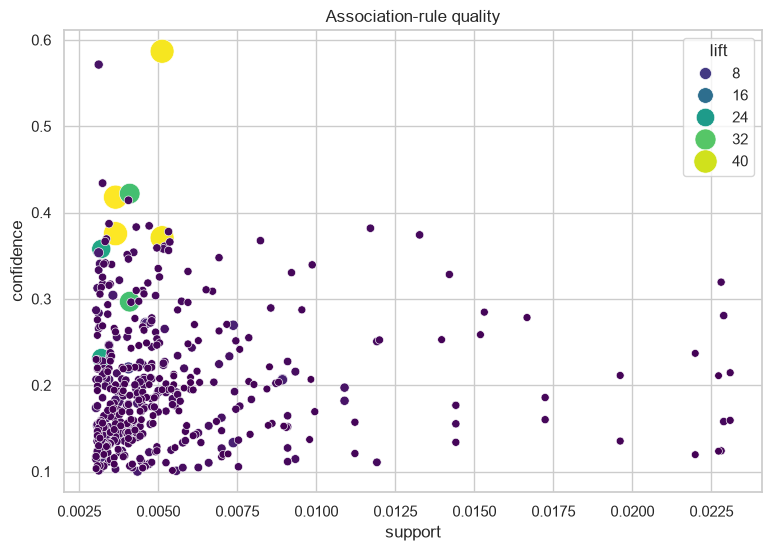

In [14]:
rules = association_rules(fp_sets, metric="confidence", min_threshold=MIN_CONFIDENCE)
rules = rules[
    (rules.lift >= MIN_LIFT)
    & (rules.consequents.map(len) == 1)
    & np.isfinite(rules.lift)
].copy()
rules["antecedent"] = rules.antecedents.map(lambda x: ", ".join(sorted(x)))
rules["consequent"] = rules.consequents.map(lambda x: next(iter(x)))
rules["score"] = rules.confidence * np.log1p(rules.lift) * np.sqrt(rules.support)
rules = rules.sort_values(["score", "support"], ascending=False)

display(rules[[
    "antecedent", "consequent", "support", "confidence", "lift",
    "leverage", "conviction", "score"
]].head(25).style.format(precision=4))

fig, ax = plt.subplots(figsize=(9, 6))
if len(rules):
    sns.scatterplot(
        data=rules, x="support", y="confidence", size="lift", hue="lift",
        palette="viridis", sizes=(30, 300), ax=ax
    )
ax.set_title("Association-rule quality")
plt.show()

**Interpretation caution:** confidence can be high merely because a consequent
is popular. Lift corrects for its baseline frequency, but rare coincidences can
have extreme lift. Support, confidence, lift, coverage, and domain sense should
be considered together. None of these proves a causal effect.

In [15]:
def recommend_for_basket(items, rule_frame=rules, k=10):
    """Return top rule-based complements whose antecedents fit the basket."""
    basket_set = set(items)
    candidates = rule_frame[
        rule_frame.antecedents.map(lambda a: set(a).issubset(basket_set))
        & ~rule_frame.consequent.isin(basket_set)
    ]
    if candidates.empty:
        return pd.DataFrame(columns=["product", "score", "confidence", "lift"])
    return (
        candidates.groupby("consequent", as_index=False)
        .agg(score=("score", "max"), confidence=("confidence", "max"), lift=("lift", "max"))
        .sort_values("score", ascending=False).head(k)
        .rename(columns={"consequent": "product"})
    )


example_items = list(rules.iloc[0].antecedents) if len(rules) else []
print("Example basket:", example_items)
display(recommend_for_basket(example_items, k=TOP_K))

Example basket: ['Total 2% Lowfat Greek Strained Yogurt With Blueberry']


,product,score,confidence,lift
1,Total 2% with Strawberry Lowfat Greek Strained...,0.158426,0.586854,42.530405
0,Total 2% Lowfat Greek Strained Yogurt with Peach,0.095484,0.417840,43.058715


## Held-out next-basket evaluation

For each selected validation order, its user's immediately preceding basket is
the query. The target is the set of retained products in the held-out basket.
Metrics are computed only when the query triggers at least one rule. This is
reported together with **coverage**, so abstention cannot be hidden.

In [16]:
meta_lookup = orders.set_index(["user_id", "order_number"]).order_id
valid_meta = sampled_meta[sampled_meta.split == "validation"].copy()
valid_meta["previous_order_id"] = [
    meta_lookup.get((u, n - 1), np.nan)
    for u, n in zip(valid_meta.user_id, valid_meta.order_number)
]
valid_meta = valid_meta.dropna(subset=["previous_order_id"]).head(1_000)
valid_meta["previous_order_id"] = valid_meta.previous_order_id.astype("int32")

needed = set(valid_meta.order_id) | set(valid_meta.previous_order_id)
eval_items = prior[prior.order_id.isin(needed) & prior.product_id.isin(popular_ids)].copy()
eval_items["product_name"] = eval_items.product_id.map(name_map)
order_products = eval_items.groupby("order_id", observed=True).product_name.apply(set).to_dict()

rows = []
for row in valid_meta.itertuples():
    query = order_products.get(row.previous_order_id, set())
    actual = order_products.get(row.order_id, set())
    predicted = recommend_for_basket(query, k=TOP_K)["product"].tolist()
    if not query or not actual:
        continue
    hits = len(set(predicted) & actual)
    rows.append({
        "has_recommendation": bool(predicted),
        "hit_rate": float(hits > 0),
        "precision_at_k": hits / TOP_K,
        "recall_at_k": hits / len(actual),
    })

evaluation = pd.DataFrame(rows)
coverage = evaluation.has_recommendation.mean() if len(evaluation) else np.nan
covered = evaluation[evaluation.has_recommendation]
metrics = pd.Series({
    "eligible_orders": len(evaluation),
    "coverage": coverage,
    f"hit_rate@{TOP_K}_when_covered": covered.hit_rate.mean(),
    f"precision@{TOP_K}_when_covered": covered.precision_at_k.mean(),
    f"recall@{TOP_K}_when_covered": covered.recall_at_k.mean(),
})
display(metrics.to_frame("value"))

,value
eligible_orders,699.000000
coverage,0.927039
hit_rate@10_when_covered,0.342593
precision@10_when_covered,0.045370
recall@10_when_covered,0.098205


## Industrial interpretation and critical analysis

- **Why useful:** rules are explainable, need no relevance labels, and naturally
  convert transaction history into product-pair candidates.
- **Why insufficient:** global co-occurrence ignores store, inventory, price,
  promotions, dietary needs, sequence, seasonality, and individual intent.
- **Scalability:** Apriori repeatedly scans data and may generate huge candidate
  sets. FP-Growth avoids that enumeration, but its tree can still consume large
  memory. Platform-scale work suggests distributed FP-Growth, partitioned or
  approximate pair counts, embeddings/graph retrieval, and learned ranking.
- **Evaluation:** offline overlap can reward already-obvious popular products.
  Measure diversity, novelty, latency, memory and calibration; confirm incremental
  impact, customer value, and guardrails through randomized online experiments.
- **Responsible use:** aggregate/anonymize data; suppress rare patterns; audit
  exposure bias; filter unavailable/inappropriate items; monitor drift.

Instacart's public docs describe co-purchase scoring plus ML relevance ranking,
not these exact algorithms. Its 2026 engineering post describes LLM-generated
discovery placements evaluated with human/automated checks and a fine-tuned
DeBERTa relevance classifier. A grounded architecture can therefore use rules
for explainable retrieval, learned models for contextual ranking, and foundation
models for semantic discovery—without letting generation invent catalog facts.

## Conclusion

Apriori makes frequent-itemset logic easy to teach and audit; FP-Growth is the
more scalable baseline on this transaction sample. Rule quality must be judged
with support, confidence and lift together, and held-out results must include
coverage. Real enterprise recommendations require a layered retrieval, filtering,
ranking, and experimentation system rather than association rules alone.

### Sources

1. Instacart Docs, *Recommendations*: https://docs.instacart.com/storefront/concepts/recommendations/
2. Instacart, *3 Million Instacart Orders, Open Sourced* (2017): https://tech.instacart.com/3-million-instacart-orders-open-sourced-d40d29ead6f2
3. Kaggle competition data: https://www.kaggle.com/competitions/instacart-market-basket-analysis/data
4. Instacart, *Supercharging ML/AI Foundations* (2023): https://company.instacart.com/tech-innovation/supercharging-ml-ai-foundations-at-instacart
5. Instacart, *Distributed Machine Learning* (2023): https://company.instacart.com/tech-innovation/distributed-machine-learning-at-instacart
6. Instacart, *Our Early Journey ... with LLMs* (2026): https://company.instacart.com/tech-innovation/our-early-journey-to-transform-instacart-s-discovery-recommendations-with-llms
7. Agrawal et al., *Mining Association Rules* (1993): https://doi.org/10.1145/170035.170072
8. Han et al., *Mining Frequent Patterns without Candidate Generation* (2000): https://doi.org/10.1145/342009.335372

## AI usage declaration

ChatGPT/Codex assisted with literature-search planning, code scaffolding,
explanations, and editorial review. Claims were verified against official
Instacart/Kaggle pages and original algorithm papers. Verification corrected a
potential overclaim: no cited public source establishes Apriori or FP-Growth as
Instacart's production algorithm. Students must execute, inspect, and explain all
results and adapt this declaration to accurately describe their own use.